# Import Library

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, LabelEncoder
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.special import inv_boxcox

# Load Dataset

In [77]:
df_train = pd.read_csv('./dataset/train_dataset.csv')
df_test = pd.read_csv('./dataset/test_dataset_no_y.csv')

In [78]:
df_train.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.407166,E,W,2.0,M,C,1.127628,-0.657689,-0.415323,76.124758,20.710704
1,44.417166,M,W,1.0,H,C,0.957628,-0.667689,-0.475323,85.834758,94.202404
2,28.047166,M,W,4.0,L,R,0.717628,-1.107689,-0.385323,13.814758,43.043004
3,-0.462834,NaN,W,2.0,L,C,1.717628,-1.547689,-0.425323,29.344758,7.956004
4,42.957166,M,W,3.0,M,C,0.747628,-1.847689,-0.135323,NaN,62.397804


In [79]:
df_test.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,16.787166,N,W,2.0,L,C,2.807628,-0.687689,-0.175323,103.314758
1,38.137166,M,NaN,1.0,M,C,2.197628,-0.617689,-0.195323,14.644758
2,20.797166,E,W,1.0,M,S,3.007628,-0.687689,-0.235323,41.574758
3,15.577166,A,W,4.0,M,C,0.707628,-0.827689,-0.125323,107.614758
4,44.677166,M,W,4.0,L,C,3.027628,-0.447689,-0.345323,92.434758


In [80]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      757 non-null    float64
 1   x2      760 non-null    object 
 2   x3      762 non-null    object 
 3   x4      764 non-null    float64
 4   x5      758 non-null    object 
 5   x6      761 non-null    object 
 6   x7      761 non-null    float64
 7   x8      756 non-null    float64
 8   x9      763 non-null    float64
 9   x10     758 non-null    float64
 10  y       758 non-null    float64
dtypes: float64(7), object(4)
memory usage: 68.9+ KB


In [81]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      186 non-null    float64
 1   x2      183 non-null    object 
 2   x3      182 non-null    object 
 3   x4      180 non-null    float64
 4   x5      185 non-null    object 
 5   x6      182 non-null    object 
 6   x7      183 non-null    float64
 7   x8      187 non-null    float64
 8   x9      181 non-null    float64
 9   x10     185 non-null    float64
dtypes: float64(6), object(4)
memory usage: 15.2+ KB


## Memisahkkan Data Kategorikal dengan Numerik

In [82]:
numeric_cols = df_train.select_dtypes(['number']).drop(['x4', 'y'], axis=1).columns.to_list()

categorical_cols = df_train.select_dtypes(['object']).columns.to_list()
categorical_cols.append('x4')

In [83]:
numeric_cols

['x1', 'x7', 'x8', 'x9', 'x10']

In [84]:
categorical_cols

['x2', 'x3', 'x5', 'x6', 'x4']

# Data Cleaning

## Cek Duplikat

Tahap ini dilakukan pengecekan data duplikat pada dataset train dan test untuk memastikan tidak ada data yang double atau tercatat lebih dari satu kali.

In [85]:
df_train.duplicated().sum()

np.int64(0)

In [86]:
df_test.duplicated().sum()

np.int64(0)

Pengecekan data duplikat dilakukan menggunakan fungsi duplicated() pada dataset train dan test, kemudian jumlah data duplikat dapat dihitung dengan fungsi sum(). Hasil pengecekan menunjukkan bahwa tidak terdapat data duplikat pada kedua dataset tersebut, yang ditandai dengan nilai output 0.

## Cek Missing Value

Tahap ini dilakukan pengecekan data yang hilang pada dataset train dan test untuk memastikan tidak terdapat nilai kosong (missing values) yang dapat memengaruhi proses analisis dan pemodelan data.

In [87]:
df_train.isna().sum() 

x1     43
x2     40
x3     38
x4     36
x5     42
x6     39
x7     39
x8     44
x9     37
x10    42
y      42
dtype: int64

In [88]:
df_test.isna().sum()

x1      7
x2     10
x3     11
x4     13
x5      8
x6     11
x7     10
x8      6
x9     12
x10     8
dtype: int64

Pengecekan data yang hilang dilakukan menggunakan fungsi isna() pada dataset train dan test, kemudian jumlah data yang hilang dapat dihitung dengan fungsi sum(). Hasil pengecekan menunjukkan bahwa cukup banyak data yang hilang pada dataset train maupun test, sehingga terdapat 2 pilihan yang harus dilakukan yaitu menghapus baris pada data yang hilang atau melakukan imputasi pada data yang hilang. Karena pada kedua dataset cukup banyak, melakukan imputasi menggunakan mean() atau median() pada variabel numerik seharusnya tidak disarankan karena dapat merusak keaslian data, namun untuk case pada project ini di mana dataset merupakan dataset dummy, jadi saya akan mengatasi missing value dengan melakukan imputasi

## Handle Outlier

<Axes: >

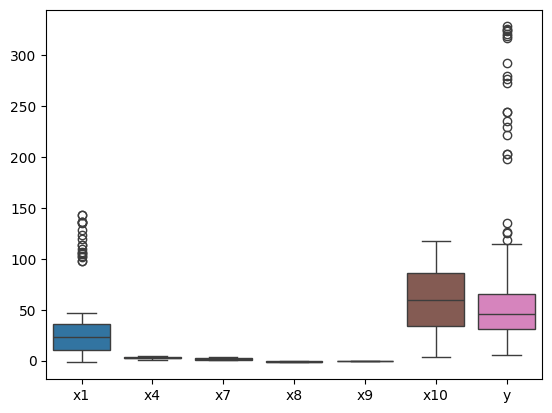

In [89]:
sns.boxplot(df_train)

In [90]:
# def handle_outliers_fixed(df):
#     numeric_cols = df.select_dtypes(include=['number']).columns
#     df_result = df.copy()
    
#     for col in numeric_cols:
#         Q1 = df_result[col].quantile(0.25)
#         Q3 = df_result[col].quantile(0.75)
#         IQR = Q3 - Q1
#         lower_bound = Q1 - 1.5 * IQR
#         upper_bound = Q3 + 1.5 * IQR
        
#         median_value = df_result[col].median()
        
#         # Penggantian nilai hanya pada kolom numerik
#         outlier_mask = (df_result[col] < lower_bound) | (df_result[col] > upper_bound)
#         df_result[col] = df_result[col].where(~outlier_mask, median_value)

#     return df_result

# df_train = handle_outliers_fixed(df_train)

Sebelumnya, saya telah menggunakan metode IQR untuk melakukan handle outlier, namun setelah saya bandingkan dengan menggunakan Z-Score, Hasil Evaluasi model lebih baik ketika handle outlier dengan Z-Score

In [91]:
z_scores = np.abs(stats.zscore(df_train[numeric_cols].fillna(df_train[numeric_cols].mean())))
df_train = df_train[(z_scores < 3).all(axis=1)].reset_index(drop=True)

$$
z = \frac{x - \mu}{\sigma}
$$

dengan:
- $x$ : nilai asli data  
- $\mu$ : rata-rata (mean) data  
- $\sigma$ : standar deviasi data  
- $z$ : nilai hasil scaling

<Axes: >

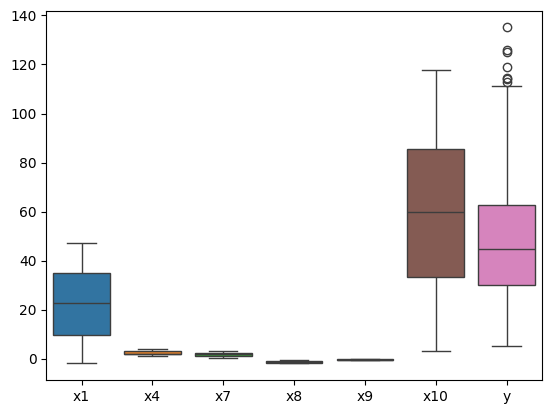

In [92]:
sns.boxplot(df_train)

In [93]:
df_train.isna().sum()

x1     43
x2     38
x3     38
x4     35
x5     42
x6     38
x7     39
x8     42
x9     35
x10    42
y      42
dtype: int64

## Cek Distribusi Data

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x7'}>],
       [<Axes: title={'center': 'x8'}>, <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: >]], dtype=object)

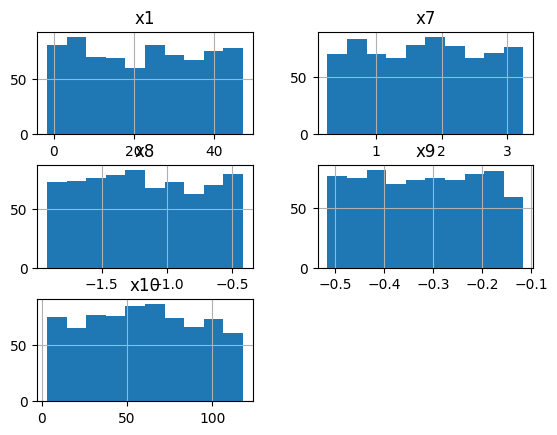

In [94]:
df_train[numeric_cols].hist()

Dilihat dari hasil visualisasi Histogram pada gambar di atas keseluruhan variabel bertipe data numerik memiliki distribusi yang cukup normal sehingga untuk melakukan imputasi pada missing value dapat menggunakan mean

## Handle Missing Value

In [95]:
df_train.isna().sum()

x1     43
x2     38
x3     38
x4     35
x5     42
x6     38
x7     39
x8     42
x9     35
x10    42
y      42
dtype: int64

In [96]:
df_test.isna().sum()

x1      7
x2     10
x3     11
x4     13
x5      8
x6     11
x7     10
x8      6
x9     12
x10     8
dtype: int64

### Handle Missing Value pada Variabel bertipe Data Numerik

In [97]:
df_train[numeric_cols] = df_train[numeric_cols].fillna(df_train[numeric_cols].mean())

In [98]:
df_train[numeric_cols].isna().sum()

x1     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

In [99]:
df_test[numeric_cols] = df_test[numeric_cols].fillna(df_test[numeric_cols].mean())

In [100]:
df_test[numeric_cols].isna().sum()

x1     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

### Handle Missing Value pada Variabel bertipe Data Kategorikal

Untuk menangani missing value pada variabel yang bertipe data kategorikal kita dapat menggunakan modus dari variabel tersebut

In [101]:
categorical_cols

['x2', 'x3', 'x5', 'x6', 'x4']

In [102]:
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Training Variabel {col}: ', df_train[col].isna().sum())
print('===============================================================================')
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Testing Variabel {col}: ', df_test[col].isna().sum())

Jumlah Missing Value pada Data Training Variabel x2:  38
Jumlah Missing Value pada Data Training Variabel x3:  38
Jumlah Missing Value pada Data Training Variabel x5:  42
Jumlah Missing Value pada Data Training Variabel x6:  38
Jumlah Missing Value pada Data Training Variabel x4:  35
Jumlah Missing Value pada Data Testing Variabel x2:  10
Jumlah Missing Value pada Data Testing Variabel x3:  11
Jumlah Missing Value pada Data Testing Variabel x5:  8
Jumlah Missing Value pada Data Testing Variabel x6:  11
Jumlah Missing Value pada Data Testing Variabel x4:  13


In [103]:
print(df_train['x2'].value_counts())
print(df_test['x2'].value_counts())

x2
A    294
M    212
E    160
N     77
Name: count, dtype: int64
x2
A    66
M    64
E    39
N    14
Name: count, dtype: int64


In [104]:
df_train['x2'] = df_train['x2'].fillna('A')
df_test['x2'] = df_test['x2'].fillna('A')

In [105]:
print(df_train['x3'].value_counts())
print(df_test['x3'].value_counts())

x3
W    743
Name: count, dtype: int64
x3
W    182
Name: count, dtype: int64


In [106]:
df_train['x3'] = df_train['x3'].fillna('W')
df_test['x3'] = df_test['x3'].fillna('W')

In [107]:
print(df_train['x5'].value_counts())
print(df_test['x5'].value_counts())

x5
L    306
M    287
H    146
Name: count, dtype: int64
x5
L    83
M    77
H    25
Name: count, dtype: int64


In [108]:
df_train['x5'] = df_train['x5'].fillna('L')
df_test['x5'] = df_test['x5'].fillna('L')

In [109]:
print(df_train['x4'].value_counts())
print(df_test['x4'].value_counts())

x4
3.0    209
2.0    195
1.0    180
4.0    162
Name: count, dtype: int64
x4
4.0    53
1.0    49
2.0    40
3.0    38
Name: count, dtype: int64


In [110]:
df_train['x4'] = df_train['x4'].fillna(3)
df_test['x4'] = df_test['x4'].fillna(4)

In [111]:
print(df_train['x6'].value_counts())
print(df_test['x6'].value_counts())

x6
C    521
R    184
S     38
Name: count, dtype: int64
x6
C    133
R     33
S     16
Name: count, dtype: int64


In [112]:
df_train['x6'] = df_train['x6'].fillna('C')
df_test['x6'] = df_test['x6'].fillna('C')

In [113]:
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Training Variabel {col}: ', df_train[col].isna().sum())
print('===============================================================================')
for col in categorical_cols :
    print(f'Jumlah Missing Value pada Data Testing Variabel {col}: ', df_test[col].isna().sum())

Jumlah Missing Value pada Data Training Variabel x2:  0
Jumlah Missing Value pada Data Training Variabel x3:  0
Jumlah Missing Value pada Data Training Variabel x5:  0
Jumlah Missing Value pada Data Training Variabel x6:  0
Jumlah Missing Value pada Data Training Variabel x4:  0
Jumlah Missing Value pada Data Testing Variabel x2:  0
Jumlah Missing Value pada Data Testing Variabel x3:  0
Jumlah Missing Value pada Data Testing Variabel x5:  0
Jumlah Missing Value pada Data Testing Variabel x6:  0
Jumlah Missing Value pada Data Testing Variabel x4:  0


# Exploratory Data Analysis

## Cek Korelasi

Melakukan Analisis Korelasi untuk melihat variabel mana yang memiliki hubungan antara satu dengan yang lain

## Variabel Numerik

In [114]:
df_train[numeric_cols]

,x1,x7,x8,x9,x10
0,0.407166,1.127628,-0.657689,-0.415323,76.124758
1,44.417166,0.957628,-0.667689,-0.475323,85.834758
2,28.047166,0.717628,-1.107689,-0.385323,13.814758
3,-0.462834,1.717628,-1.547689,-0.425323,29.344758
4,42.957166,0.747628,-1.847689,-0.135323,59.447803
...,...,...,...,...,...
776,18.237166,2.857628,-1.727689,-0.435323,82.144758
777,37.787166,2.147628,-1.747689,-0.315323,32.374758
778,36.127166,0.437628,-0.857689,-0.185323,62.894758
779,32.477166,2.447628,-1.207689,-0.465323,77.094758


In [115]:
df_numeric_corr = df_train[['x1', 'x7', 'x8', 'x9', 'x10', 'y']].corr(method='pearson')
df_numeric_corr

,x1,x7,x8,x9,x10,y
x1,1.000000,0.050534,-0.082917,0.022447,-0.032445,0.681723
x7,0.050534,1.000000,-0.003022,-0.036367,-0.005377,0.041359
x8,-0.082917,-0.003022,1.000000,0.034573,0.009264,0.378532
x9,0.022447,-0.036367,0.034573,1.000000,-0.037235,0.289483
x10,-0.032445,-0.005377,0.009264,-0.037235,1.000000,0.343730
y,0.681723,0.041359,0.378532,0.289483,0.343730,1.000000


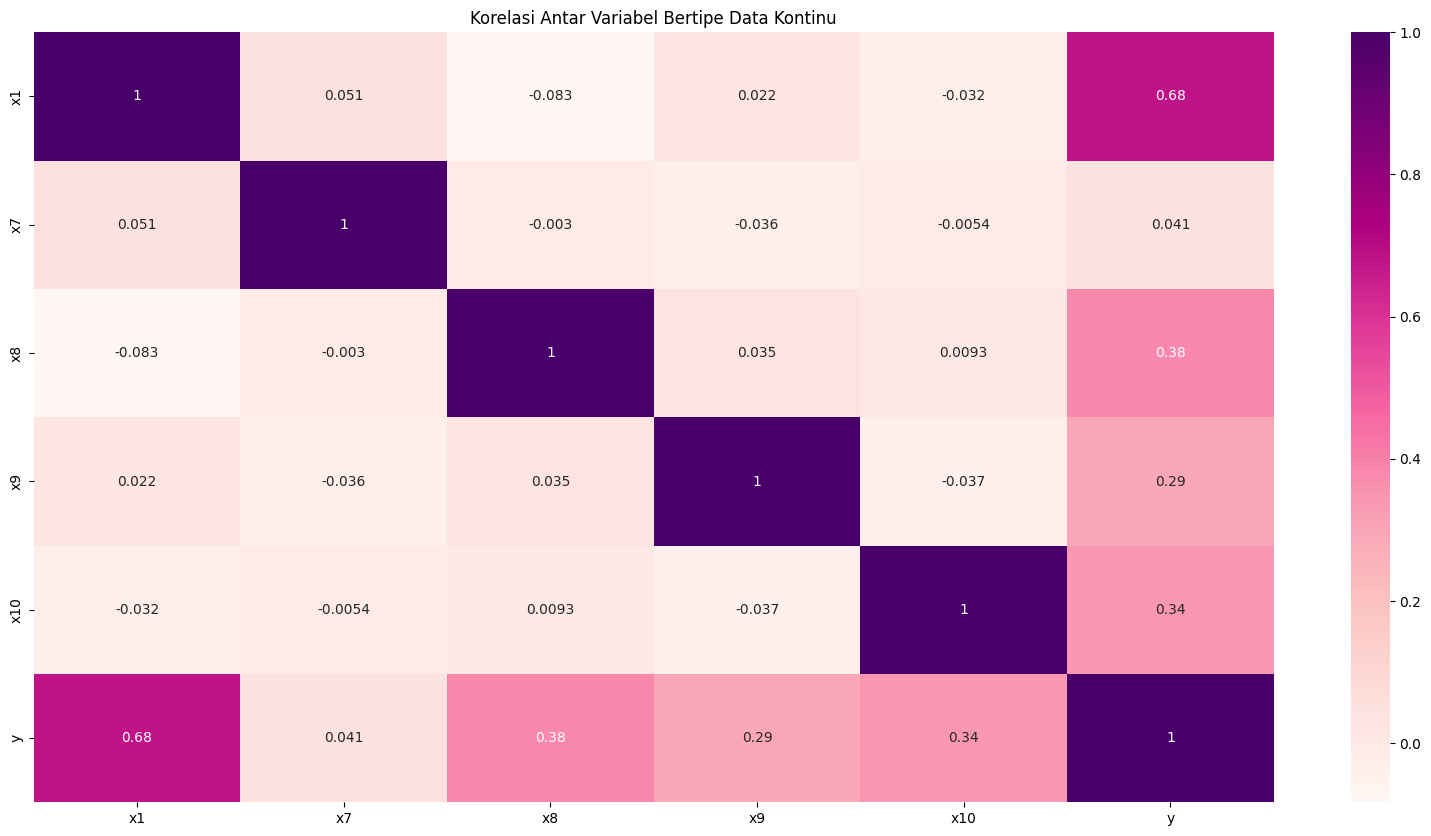

In [116]:
plt.figure(figsize=(20, 10))
plt.title('Korelasi Antar Variabel Bertipe Data Kontinu')
sns.heatmap(df_numeric_corr, annot=True, cmap='RdPu')
plt.show()

Berdasarkan visualisasi heatmap, terlihat bahwa variabel X7 tidak memiliki hubungan yang kuat dengan variabel Y, sehingga variabel X7 berpotensi untuk dihapus pada tahap feature Selection.

## Menghapus Missing Value pada Variabel Dependen

In [117]:
df_train = df_train.dropna(subset=['y']).reset_index(drop=True)

In [118]:
df_train.isna().sum()

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
y      0
dtype: int64

In [119]:
df_test.isna().sum()

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
dtype: int64

## Encode Data Bertipe Kategorikal

Mengubah tipe data Kategorikal menjadi Numerik dengan melakukan encoding pada variabel kategorikal

In [120]:
le = LabelEncoder()

df_train['x2'] = le.fit_transform(df_train['x2'])
df_train['x5'] = le.fit_transform(df_train['x5'])
df_train['x3'] = le.fit_transform(df_train['x3'])
df_train['x6'] = le.fit_transform(df_train['x6'])

df_train

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.407166,1,0,2.0,2,0,1.127628,-0.657689,-0.415323,76.124758,20.710704
1,44.417166,2,0,1.0,0,0,0.957628,-0.667689,-0.475323,85.834758,94.202404
2,28.047166,2,0,4.0,1,1,0.717628,-1.107689,-0.385323,13.814758,43.043004
3,-0.462834,0,0,2.0,1,0,1.717628,-1.547689,-0.425323,29.344758,7.956004
4,42.957166,2,0,3.0,2,0,0.747628,-1.847689,-0.135323,59.447803,62.397804
...,...,...,...,...,...,...,...,...,...,...,...
734,18.237166,0,0,4.0,0,1,2.857628,-1.727689,-0.435323,82.144758,30.756604
735,37.787166,0,0,2.0,2,0,2.147628,-1.747689,-0.315323,32.374758,37.879104
736,36.127166,1,0,1.0,1,0,0.437628,-0.857689,-0.185323,62.894758,87.348204
737,32.477166,2,0,1.0,2,0,2.447628,-1.207689,-0.465323,77.094758,55.274904


In [121]:
df_test['x2'] = le.fit_transform(df_test['x2'])
df_test['x5'] = le.fit_transform(df_test['x5'])
df_test['x3'] = le.fit_transform(df_test['x3'])
df_test['x6'] = le.fit_transform(df_test['x6'])

df_test

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10
0,16.787166,3,0,2.0,1,0,2.807628,-0.687689,-0.175323,103.314758
1,38.137166,2,0,1.0,2,0,2.197628,-0.617689,-0.195323,14.644758
2,20.797166,1,0,1.0,2,2,3.007628,-0.687689,-0.235323,41.574758
3,15.577166,0,0,4.0,2,0,0.707628,-0.827689,-0.125323,107.614758
4,44.677166,2,0,4.0,1,0,3.027628,-0.447689,-0.345323,92.434758
...,...,...,...,...,...,...,...,...,...,...
188,42.487166,0,0,4.0,2,1,0.907628,-0.637689,-0.355323,66.764758
189,-1.162834,2,0,4.0,0,0,2.697628,-1.147689,-0.435323,85.934758
190,-1.622834,0,0,3.0,1,1,2.217628,-0.927689,-0.305323,10.884758
191,2.137166,0,0,4.0,1,1,1.877628,-1.627689,-0.245323,56.104758


In [122]:
df_train['y']

0      20.710704
1      94.202404
2      43.043004
3       7.956004
4      62.397804
         ...    
734    30.756604
735    37.879104
736    87.348204
737    55.274904
738    50.383104
Name: y, Length: 739, dtype: float64

## Scaling Data

Melakukan Scaling pada Variabel supaya skala data seragam

$$
z = \frac{x - \mu}{\sigma}
$$

dengan:
- $x$ : nilai asli data  
- $\mu$ : rata-rata (mean) data  
- $\sigma$ : standar deviasi data  
- $z$ : nilai hasil scaling

In [123]:
scaler = StandardScaler()
df_train[numeric_cols] = scaler.fit_transform(df_train[numeric_cols])
df_test[numeric_cols] = scaler.fit_transform(df_test[numeric_cols])

In [124]:
df_train

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,-1.576997,1,0,2.0,2,0,-0.731812,1.251794,-0.825281,0.543399,20.710704
1,1.572450,2,0,1.0,0,0,-0.934732,1.228010,-1.356052,0.854569,94.202404
2,0.400979,2,0,4.0,1,1,-1.221206,0.181551,-0.559896,-1.453413,43.043004
3,-1.639256,0,0,2.0,1,0,-0.027562,-0.864908,-0.913743,-0.955732,7.956004
4,1.467969,2,0,3.0,2,0,-1.185397,-1.578403,1.651651,0.008962,62.397804
...,...,...,...,...,...,...,...,...,...,...,...
734,-0.301045,0,0,4.0,0,1,1.333192,-1.293005,-1.002205,0.736318,30.756604
735,1.097993,0,0,2.0,2,0,0.485705,-1.340571,0.059337,-0.858631,37.879104
736,0.979200,1,0,1.0,1,0,-1.555427,0.776130,1.209341,0.119425,87.348204
737,0.717999,2,0,1.0,2,0,0.843798,-0.056280,-1.267591,0.574484,55.274904


Pada scaling ini rumus yang digunakan sama dengan handle outlier, sama-sama menggunakan z-score. Perbedaan utamanya terletak pada tujuan, menghapus outlier dengan Z-Score adalah proses pembersihan untuk menghandle baris data ekstrem agar tidak merusak distribusi, sedangkan StandardScaler adalah proses transformasi untuk menyamakan skala fitur

# Modelling

Melakukan Feature Selection di mana Feature Selection iini menyeleksi fitur yang tidak signifikan

In [125]:
X = df_train.drop(['y', 'x2', 'x3', 'x4', 'x7'], axis=1)
y = df_train['y']
X_test = df_test.drop(['x2', 'x3', 'x4', 'x7'], axis=1)

Mengubah fungsi menjadi fungsi polinomial kuadrat, karena dari percobaan sebelum-sebelumnya hasil OLS dari penggunaan Linear Regression kurang memuaskan jadi saya ubah menjadi non-linear

In [126]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly.fit_transform(X)
X_test_poly = poly.fit_transform(X_test)

Fungsi Polinomial derajat dua dilakukan untuk menambahkan fitur kuadrat dari setiap variabel prediktor sehingga model mampu menangkap pola yang non-linear, saya sudah melakukan percobaan terhadap fungsi polinomial derajat 3 dan 4 yang dihasilkan model overfitting, jadi disini saya menggunakan fungsi polinomial degree 2 yang artinya nanti nilai-nilai dari variabel prediktor akan ditransformasi ke bentuk kuadrat, sehingga rumus regresinya nanti akan seperti ini :

$$
y = \sum_{i=1}^{n} \beta_i x_i 
+ \sum_{i=1}^{n} \beta_{ii} x_i^2 
+ \varepsilon
$$

## Split Data (80% Data Training, 20% Data Testing)

Dataset dibagi menjadi data latih dan data validasi, data latih digunakan untuk melatih model, sedangkan data validasi digunakan untuk mengevaluasi kinerja model dan mengukur kemampuan model terhadap data yang belum pernah dilihat sebelumnya. Kalau hanya memprediksi data training, hasil tersebut hanya menunjukkan seberapa baik model "menghafal" pola data yang sudah dipelajari sebelumnya, jadi ada kemungkinan bisa terjadi overfitting.

In [127]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X_poly, 
    y, 
    test_size=0.2,
    random_state=42 
)

Di projek ini, data validasi digunakan karena data testing tidak memiliki variabel dependen (y) untuk dihitung hasil evaluasinya. Dengan menggunakan data validation ini, data dipisahkan sebesar 20% untuk mensimulasikan data baru yang belum dikenal model. Data Y_val berfungsi sebagai acuan untuk mengevaluasi seberapa akurat prediksi model.

In [128]:
Y_train, lam = stats.boxcox(Y_train)

Box-Cox digunakan untuk melakukan transformasi pada variabel \(Y\) agar distribusi data menjadi lebih seimbang.

\(
\begin{cases}
\dfrac{Y^{\lambda} - 1}{\lambda}, & \text{jika } \lambda \neq 0 \\
\ln(Y), & \text{jika } \lambda = 0
\end{cases}
\)

In [129]:
X_constant = sm.add_constant(X_train)

$$
y = \beta_0 
+ \sum_{i=1}^{n} \beta_i x_i 
+ \sum_{i=1}^{n} \beta_{ii} x_i^2 
+ \varepsilon
$$


Menambahkan konstanta pada fungsi regresi dilakukan karena model tanpa konstanta menghasilkan nilai R-squared yang sangat tinggi pada data training, namun menunjukkan kinerja yang buruk pada data validation. Hal ini mengindikasikan bahwa model tanpa konstanta cenderung mengalami overfitting

In [130]:
X_constant

array([[ 1.00000000e+00, -1.70151501e+00,  0.00000000e+00, ...,
         5.88338071e-01, -1.25246540e+00,  2.66627244e+00],
       [ 1.00000000e+00,  1.12590255e+00,  0.00000000e+00, ...,
         2.92375770e+00,  1.60954772e+00,  8.86066543e-01],
       [ 1.00000000e+00, -1.67646828e+00,  1.00000000e+00, ...,
         1.06588599e+00,  1.75406921e+00,  2.88657400e+00],
       ...,
       [ 1.00000000e+00,  4.33897289e-01,  0.00000000e+00, ...,
         6.81089348e-01,  7.46696578e-01,  8.18623550e-01],
       [ 1.00000000e+00,  1.02857813e+00,  2.00000000e+00, ...,
         5.88338071e-01,  6.87440014e-03,  8.03235072e-05],
       [ 1.00000000e+00, -2.05867655e-01,  0.00000000e+00, ...,
         3.13483323e-01, -3.58246990e-02,  4.09402660e-03]],
      shape=(591, 28))

In [131]:
model = sm.OLS(Y_train, X_constant).fit()

print("Hasil Regresi:")
print(model.summary())

Hasil Regresi:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.950
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     392.4
Date:                Tue, 30 Dec 2025   Prob (F-statistic):               0.00
Time:                        00:28:10   Log-Likelihood:                -703.08
No. Observations:                 591   AIC:                             1462.
Df Residuals:                     563   BIC:                             1585.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         11.9617      0.112    1

Hasil OLS menunjukkan bahwa model regresi yang dibangun telah memiliki kinerja yang cukup baik. Nilai R-squared sebesar 0,951 mengindikasikan bahwa model mampu menjelaskan sekitar 95,1% variasi pada variabel dependen.

Beberapa variabel yang terlihat p-valuenya > 0.05 merupakan variabel kategorikal hasil encoding variabel kategorikal, alasan saya tetap memasukkan ke dalam model meskipun tidak signifikan secara statistik karena berfungsi untuk merepresentasikan perbedaan antar kategori dan menjaga informasi penting dalam data. 

In [132]:
X_val_const = sm.add_constant(X_val)

In [133]:
Y_val_pred = model.predict(X_val_const)
Y_val_inv = inv_boxcox(Y_val_pred, lam)

In [134]:
mae = mean_absolute_error(Y_val, Y_val_inv)
mse = mean_squared_error(Y_val, Y_val_inv)
rmse = np.sqrt(mean_squared_error(Y_val, Y_val_inv))
r_squared = r2_score(Y_val, Y_val_inv)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r_squared:.4f}")

MAE: 3.3836
MSE: 36.4172
RMSE: 6.0347
R-squared: 0.9396


#### Mean Absolute Error (MAE)
MAE mengukur rata-rata selisih absolut antara nilai aktual dan nilai prediksi.

$$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

#### Mean Squared Error (MSE)
MSE mengukur rata-rata kuadrat selisih antara nilai aktual dan nilai prediksi.

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

#### Root Mean Squared Error (RMSE)
RMSE merupakan akar kuadrat dari MSE dan memberikan penalti lebih besar pada kesalahan
prediksi yang besar.

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

In [135]:
Y_val_pred = model.predict(X_val_const)
Y_val_pred_inv = inv_boxcox(Y_val_pred, lam)

In [136]:
mae = mean_absolute_error(Y_val, Y_val_pred_inv)
mse = mean_squared_error(Y_val, Y_val_pred_inv)
rmse = np.sqrt(mean_squared_error(Y_val, Y_val_pred_inv))
r_squared = r2_score(Y_val, Y_val_pred_inv)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R-squared: {r_squared:.4f}")

MAE: 3.3836
MSE: 36.4172
RMSE: 6.0347
R-squared: 0.9396


Hasil evaluasi menunjukkan bahwa model regresi yang dibangun telah memiliki kinerja yang cukup baik. Dengan Nilai MAE sebesar 3.1954 menandakan bahwa rata-rata kesalahan prediksi model relatif kecil, sementara MSE dan RMSE masing-masing sebesar 336.8926 dan 6.0739 menunjukkan bahwa penyimpangan prediksi masih berada dalam batas yang dapat diterima. Selain itu, nilai R-squared sebesar 0.9388 mengindikasikan bahwa model mampu menjelaskan sekitar 93,88% variasi pada variabel dependen. Dari Hasil evaluasi pada data Validation, dapat disimpulkan bahwa model melakukan prediksi dengan cukup baik, dengan penyimpangan prediksi yang kecil menjadi indikasi bahwa model tidak mengalami Overfitting

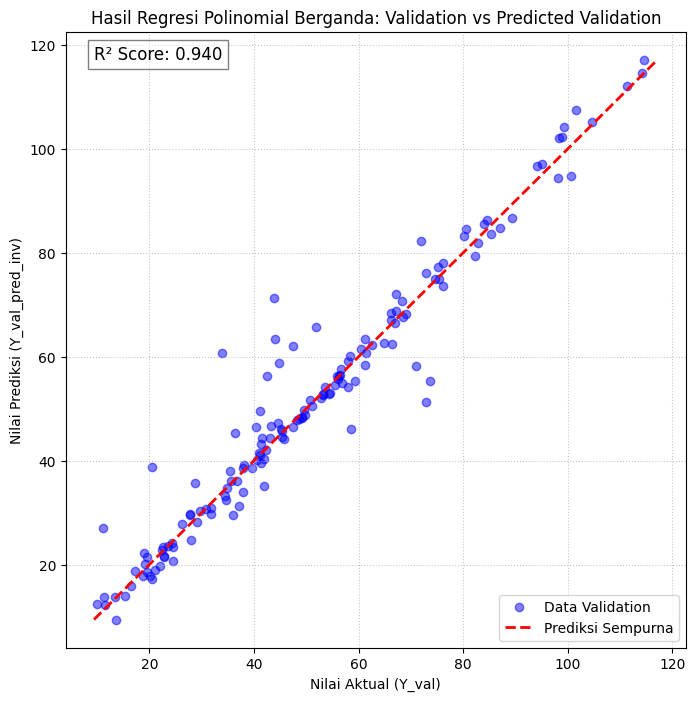

In [137]:
plt.figure(figsize=(8, 8))
plt.scatter(Y_val, Y_val_pred_inv, color='blue', alpha=0.5, label='Data Validation')

max_val = max(Y_val.max(), Y_val_pred_inv.max())
min_val = min(Y_val.min(), Y_val_pred_inv.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Prediksi Sempurna')

plt.text(min_val, max_val, f'R² Score: {r_squared:.3f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.title('Hasil Regresi Polinomial Berganda: Validation vs Predicted Validation')
plt.xlabel('Nilai Aktual (Y_val)')
plt.ylabel('Nilai Prediksi (Y_val_pred_inv)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [138]:
X_test = X_test_poly

In [139]:
X_test_const = sm.add_constant(X_test)

In [140]:
y_pred = model.predict(X_test_const)
y_pred_inv = inv_boxcox(y_pred, lam)

In [141]:
df_test['y'] = y_pred_inv
df_test

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,-0.325183,3,0,2.0,1,0,1.203921,1.245992e+00,1.282483,1.210265,80.756272
1,1.093977,2,0,1.0,2,0,0.505445,1.414450e+00,1.101978,-1.486834,79.185484
2,-0.058633,1,0,1.0,2,2,1.432929,1.245992e+00,0.740968,-0.667697,56.257658
3,-0.405613,0,0,4.0,2,0,-1.200667,9.090777e-01,1.733746,1.341059,85.502992
4,1.528699,2,0,4.0,1,0,1.455830,1.823560e+00,-0.251809,0.879325,119.842128
...,...,...,...,...,...,...,...,...,...,...,...
188,1.383127,0,0,4.0,2,1,-0.971659,1.366319e+00,-0.342062,0.098514,97.122585
189,-1.518340,2,0,4.0,0,0,1.077966,1.389870e-01,-1.064082,0.681613,19.407432
190,-1.548917,0,0,3.0,1,1,0.528346,6.684243e-01,0.109201,-1.601203,11.645033
191,-1.298986,0,0,4.0,1,1,0.139032,-1.016149e+00,0.650716,-0.225734,24.032744


In [142]:
df_result = pd.DataFrame({
    'ID': df_test['y'].index + 1,
    'y': y_pred_inv
})
df_result.to_csv('24083010002-submission-23.csv', index=False)

In [143]:
df_result


,ID,y
0,1,80.756272
1,2,79.185484
2,3,56.257658
3,4,85.502992
4,5,119.842128
...,...,...
188,189,97.122585
189,190,19.407432
190,191,11.645033
191,192,24.032744


# Uji Residual

In [144]:
residuals = model.resid

## Uji Normalitas

In [145]:
stat, p_value = shapiro(residuals)
print(f"Uji Normalitas Shapiro-Wilk: Statistik={stat:.4f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("Residual terdistribusi normal")
else:
    print("Residual tidak normal")

Uji Normalitas Shapiro-Wilk: Statistik=0.7419, p-value=0.0000
Residual tidak normal


## Uji Multikolinearitas

In [146]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data["1/VIF"] = 1 / vif_data["VIF"]
print("\nVIF:\n", vif_data)


VIF:
   feature       VIF     1/VIF
0      x1  1.010529  0.989580
1      x5  1.259142  0.794192
2      x6  1.260639  0.793248
3      x8  1.009401  0.990687
4      x9  1.004521  0.995499
5     x10  1.004507  0.995513


Seluruh variabel independen terbebas dari masalah multikolinearitas karena memiliki nilai Variance Inflation Factor (VIF) yang sangat rendah. Nilai yang jauh di bawah ambang batas kritis 5 atau 10, yang mengindikasikan bahwa tidak ada korelasi antar variabel independen yang dapat mengganggu stabilitas model. Dengan nilai VIF yang mendekati 1, setiap fitur dipastikan memberikan informasi unik sehingga estimasi koefisien regresi menjadi akurat dan valid untuk digunakan dalam pemodelan

## Uji Heteroskedastisitas

In [147]:
bp_test = het_breuschpagan(residuals, X_constant)
labels = ['LM Stat', 'LM p-value', 'F-stat', 'F p-value']
bp_result = dict(zip(labels, bp_test))
print("\nUji Breusch-Pagan:", bp_result)
if bp_result['F p-value'] > 0.05:
    print("Tidak ada heteroskedastisitas")
else:
    print("Ada heteroskedastisitas")


Uji Breusch-Pagan: {'LM Stat': np.float64(27.178273241139106), 'LM p-value': np.float64(0.45420860900963594), 'F-stat': np.float64(1.0051356666781293), 'F p-value': np.float64(0.45902484820026423)}
Tidak ada heteroskedastisitas


## Uji Autokorelasi

In [148]:
dw_stat = sm.stats.stattools.durbin_watson(residuals)
print(f"\nDurbin-Watson: {dw_stat:.3f}")


Durbin-Watson: 2.157


Hasil uji Durbin-Watson sebesar 2,168 menunjukkan bahwa tidak terdapat masalah autokorelasi yang signifikan dalam model regresi Anda.

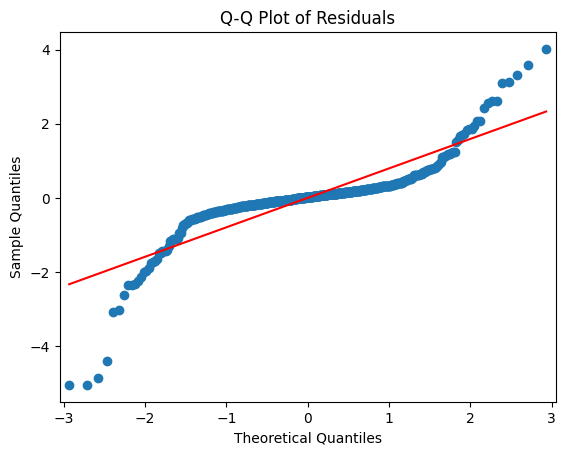

In [149]:
fig = sm.qqplot(residuals, line='s')

plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")

plt.show()

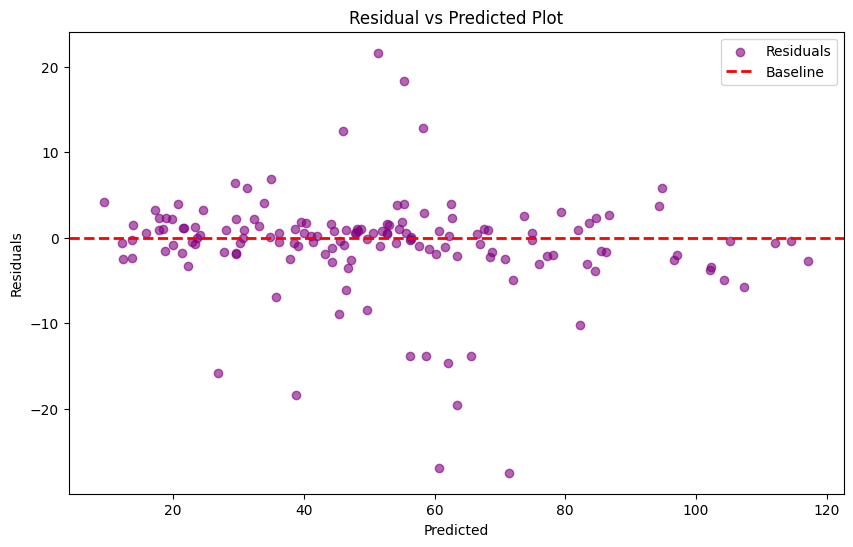

In [150]:
residuals = Y_val - Y_val_pred_inv

plt.figure(figsize=(10, 6))
plt.scatter(Y_val_pred_inv, residuals, color='purple', alpha=0.6, label='Residuals')

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Baseline')

plt.title('Residual vs Predicted Plot')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.legend()
plt.show()